# **Huellas y rastros**

Por: Daning Montaño

# **1. Librerías**

In [15]:
suppressMessages({library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)})

# **2.Carga de datos**

In [17]:
huellas_rastros_0 = read.csv("../Data/Evidencias_jaguar.csv")
huellas_rastros_0$Fecha = as.Date(huellas_rastros_0$Fecha, format = "%Y-%m-%d")

# **3.Análisis de datos**

In [18]:
huellas_rastros_0 <- huellas_rastros_0 %>%
  mutate(
    Id_taxonomica = ifelse(Nivel_taxonomico == "" | is.na(Nivel_taxonomico),
                           "No identificada",
                           "Identificada")
  )

## 3.1.Trabajo comunidades

In [19]:
conteo_actividades <- huellas_rastros_0 %>%
  # Filtramos desde el 1 de diciembre de 2024 en adelante
  filter(Fecha >= as.Date("2025-01-01")) %>%
  group_by(Comunidad,Id_taxonomica ) %>%
  summarise(Total_registros = n()) %>%
  arrange(desc(Comunidad))

# Visualizar resultado
conteo_actividades

`summarise()` has grouped output by 'Comunidad'. You can override using the `.groups` argument.


# A tibble: 9 × 3
# Groups:   Comunidad [5]
  Comunidad    Id_taxonomica   Total_registros
  <chr>        <chr>                     <int>
1 Wayusentsa   Identificada                  5
2 Wayusentsa   No identificada              44
3 Shuinmamus   Identificada                  9
4 Shuinmamus   No identificada               2
5 Sharamentsa  Identificada                  3
6 Sharamentsa  No identificada               9
7 Napurak      Identificada                  9
8 Napurak      No identificada               3
9 Hotel Kapawi No identificada               3

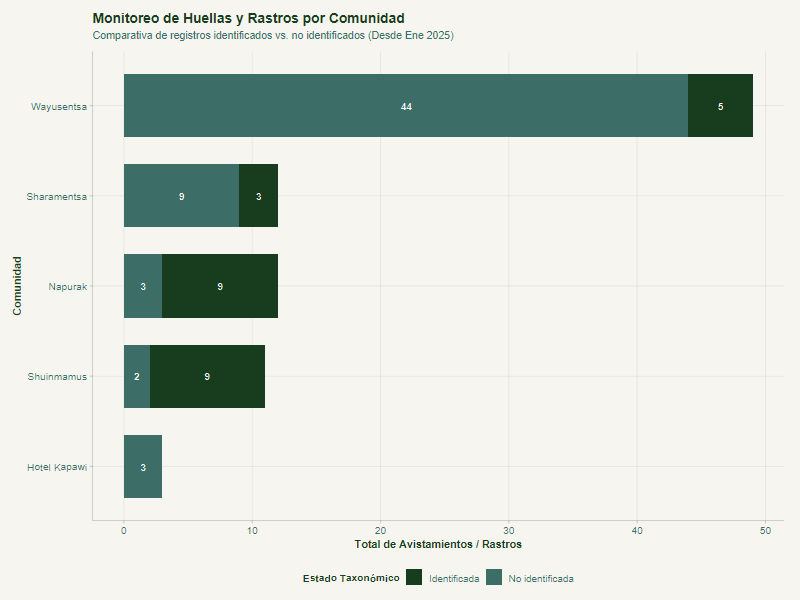

In [20]:
conteo_grafico <- conteo_actividades %>%
  group_by(Comunidad) %>%
  mutate(Porcentaje = Total_registros / sum(Total_registros) * 100) %>%
  ungroup()

ggplot(conteo_grafico, aes(x = reorder(Comunidad, Total_registros), y = Total_registros, fill = Id_taxonomica)) +
  # Barras apiladas
  geom_col(position = "stack", width = 0.7) +
  
  # Añadir etiquetas con el número total dentro de las barras
  geom_text(aes(label = Total_registros), 
            position = position_stack(vjust = 0.5), 
            color = "white", 
            fontface = "bold",
            size = 3.5) +
  
  # Colores institucionales (Verde Hoja para Identificadas, Rio para No identificadas)
  scale_fill_manual(values = c("Identificada" = PAL$hoja, "No identificada" = PAL$rio)) +
  
  # Girar coordenadas para que los nombres de las comunidades se lean bien
  coord_flip() +
  
  labs(
    title = "Monitoreo de Huellas y Rastros por Comunidad",
    subtitle = "Comparativa de registros identificados vs. no identificados (Desde Ene 2025)",
    x = "Comunidad",
    y = "Total de Avistamientos / Rastros",
    fill = "Estado Taxonómico"
  ) +
  
  theme_pachamama() +
  theme(
    legend.position = "bottom",
    text = element_text(family = "sans")
  )

## 3.2. Registros por año

### Jaguar

In [21]:
serie_anual_Registro<- huellas_rastros_0 %>%
  mutate(Year = floor_date(as.Date(Fecha), "year")) %>%
  filter(Nombre_cientifico== "Panthera onca")%>%
  group_by(Year,Comunidad ) %>%
    summarise(Total_registros = n(), .groups = "drop") 
  serie_anual_Registro

# A tibble: 4 × 3
  Year       Comunidad   Total_registros
  <date>     <chr>                 <int>
1 2025-01-01 Napurak                   4
2 2025-01-01 Sharamentsa               2
3 2025-01-01 Shuinmamus                3
4 2025-01-01 Wayusentsa                4

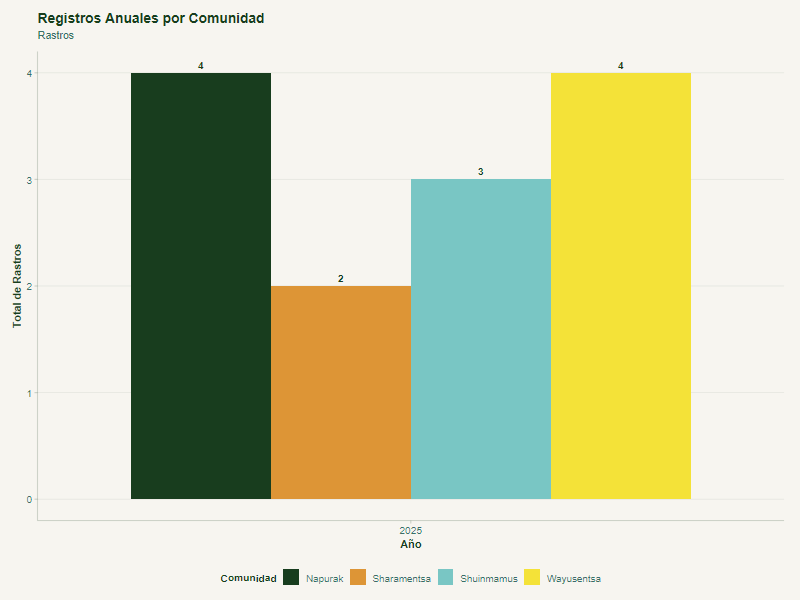

In [22]:

# Aseguramos que el año se trate como una categoría (factor) para que el eje X sea limpio
serie_anual_alimentaria <- serie_anual_Registro %>%
  mutate(Anio_Label = format(Year, "%Y"))

ggplot(serie_anual_alimentaria, aes(x = Anio_Label, y = Total_registros, fill = Comunidad)) +
  # position = "dodge" crea las barras una al lado de la otra
  geom_col(position = position_dodge(width = 0.9)) +
  
  # Añadir el total sobre cada barra
  geom_text(aes(label = Total_registros), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5,      # Ajuste vertical para que esté arriba de la barra
            size = 3.5, 
            fontface = "bold",
            color = PAL$hoja) +
  
  # Colores institucionales
  scale_fill_manual(values = PAL_CUAL) +
  
  labs(
    title = "Registros Anuales por Comunidad",
    subtitle = "Rastros",
    x = "Año",
    y = "Total de Rastros",
    fill = "Comunidad"
  ) +
  
  # Tu tema de la Fundación
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(), # Limpiamos el eje X para que se vea más moderno
    text = element_text(family = "sans")
  )

### Puma

In [23]:
serie_anual_Registro<- huellas_rastros_0 %>%
  mutate(Year = floor_date(as.Date(Fecha), "year")) %>%
  filter(Nombre_cientifico== "Puma concolor")%>%
  group_by(Year,Comunidad ) %>%
    summarise(Total_registros = n(), .groups = "drop") 
  serie_anual_Registro

# A tibble: 3 × 3
  Year       Comunidad   Total_registros
  <date>     <chr>                 <int>
1 2025-01-01 Napurak                   1
2 2025-01-01 Sharamentsa               1
3 2025-01-01 Wayusentsa                1

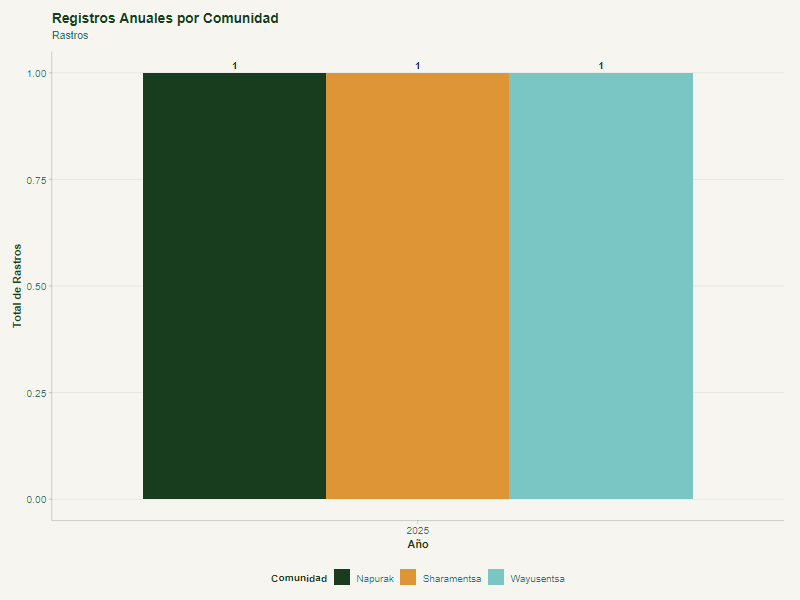

In [24]:

# Aseguramos que el año se trate como una categoría (factor) para que el eje X sea limpio
serie_anual_alimentaria <- serie_anual_Registro %>%
  mutate(Anio_Label = format(Year, "%Y"))

ggplot(serie_anual_alimentaria, aes(x = Anio_Label, y = Total_registros, fill = Comunidad)) +
  # position = "dodge" crea las barras una al lado de la otra
  geom_col(position = position_dodge(width = 0.9)) +
  
  # Añadir el total sobre cada barra
  geom_text(aes(label = Total_registros), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5,      # Ajuste vertical para que esté arriba de la barra
            size = 3.5, 
            fontface = "bold",
            color = PAL$hoja) +
  
  # Colores institucionales
  scale_fill_manual(values = PAL_CUAL) +
  
  labs(
    title = "Registros Anuales por Comunidad",
    subtitle = "Rastros",
    x = "Año",
    y = "Total de Rastros",
    fill = "Comunidad"
  ) +
  
  # Tu tema de la Fundación
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(), # Limpiamos el eje X para que se vea más moderno
    text = element_text(family = "sans")
  )

## 3.3. Descripción de Entorno del registro

In [25]:
huellas_rastros_0$Entorno

 [1] "En el camino vía napurak a awampuik"                                                            
 [2] "En la orilla del río"                                                                           
 [3] "Lindero de Suwa-Sharamentsa, se evidencio hueso y pelajes del animal que se alimento el jaguar."
 [4] "Huella de jaguar"                                                                               
 [5] "Se encontró la evidencia en el río tsuatentsa."                                                 
 [6] "Sendero kunkuk, cima de loma"                                                                   
 [7] "Sendero hotel-lobo."                                                                            
 [8] "La raspada de jaguar"                                                                           
 [9] "Camino Rafael Entsakua"                                                                         
[10] "Bosque secundario"                                                 

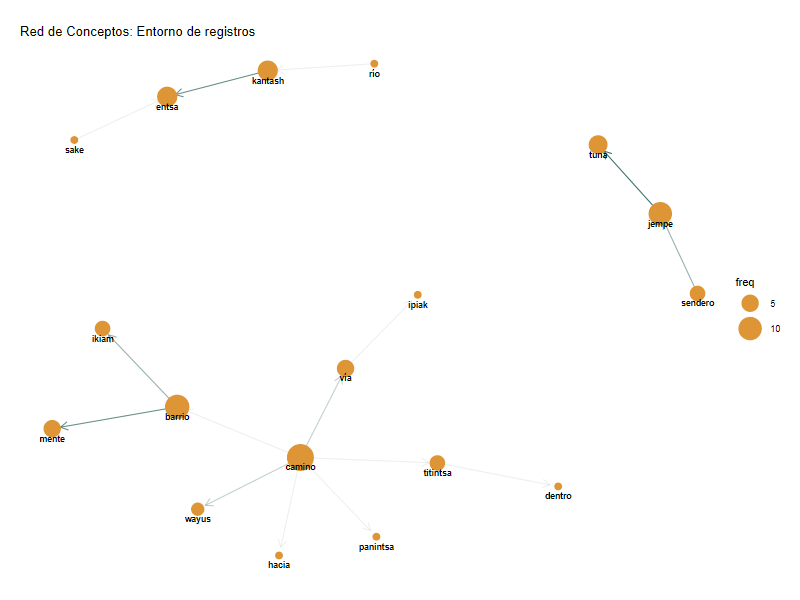

In [26]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- huellas_rastros_0 %>%
  filter(!is.na(Entorno)) %>%
  mutate(texto = str_to_lower(Entorno) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Entorno de registros",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))

## 3.4. Homologar descripción entorno

In [ ]:
S

huellas_rastros_0 <- huellas_rastros_0 %>%
  mutate(
    Entorno_limpio = Entorno %>%
      str_to_lower() %>%
      str_squish(),
    
    Entorno_homologado = case_when(
      
      # 1. Evidencia mal ubicada en entorno
      str_detect(Entorno_limpio, "huella|raspad|evidencia de puma|evidencia de tigrillo") ~ 
        "Evidencia mal ubicada en entorno",
      
      # 2. Saladero
      str_detect(Entorno_limpio, "saladero") ~ 
        "Saladero",
      
      # 3. Laguna / cuerpo de agua léntico
      str_detect(Entorno_limpio, "laguna") ~ 
        "Laguna",
      
      # 4. Orilla de río / quebrada
      str_detect(Entorno_limpio, "rio|río|quebrada|orilla") ~ 
        "Orilla de río",
      
      # 5. Bosque / vegetación secundaria
      str_detect(Entorno_limpio, "bosque secundario|bosque") ~ 
        "Bosque",
      
      # 6. Lindero / borde
      str_detect(Entorno_limpio, "lindero") ~ 
        "Lindero",
      
      # 7. Sendero
      str_detect(Entorno_limpio, "sendero|cendero") ~ 
        "Sendero",
      
      # 8. Camino / vía
      str_detect(Entorno_limpio, "camino|vía|via") ~ 
        "Camino",
      
      # 9. Sitio específico local
      str_detect(Entorno_limpio, 
                 "kantash entsa|kumpau entsa|panintsa|titintsa|jempe tuna|jempetuna|sake etsa|sake entsa|kunkus entsa|kunkuk|tsuat entsa|wampuik|wampuash|ipiak|ikiam|barrio mente|barrio memte|napurak") ~ 
        "Sitio específico local",
      
      # 10. Sin información clara
      TRUE ~ "Sin información clara"
    )
  )

In [32]:

# =========================================================
# 1. Resumen de entorno homologado
# =========================================================

resumen_entorno <- huellas_rastros_0 %>%
  filter(!is.na(Entorno_homologado), Entorno_homologado != "") %>%
  group_by(Entorno_homologado) %>%
  summarise(
    n = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(n))

resumen_entorno

# A tibble: 8 × 2
  Entorno_homologado                   n
  <chr>                            <int>
1 Camino                              31
2 Orilla de río                       25
3 Sendero                             10
4 Evidencia mal ubicada en entorno     8
5 Sitio específico local               6
6 Laguna                               3
7 Lindero                              2
8 Saladero                             2

In [33]:
# =========================================================
# 2. Top 5 de entorno homologado
# =========================================================

top5_entorno <- resumen_entorno %>%
  slice_max(order_by = n, n = 5, with_ties = FALSE) %>%
  mutate(
    Entorno_homologado = reorder(Entorno_homologado, n)
  )

top5_entorno

# A tibble: 5 × 2
  Entorno_homologado                   n
  <fct>                            <int>
1 Camino                              31
2 Orilla de río                       25
3 Sendero                             10
4 Evidencia mal ubicada en entorno     8
5 Sitio específico local               6

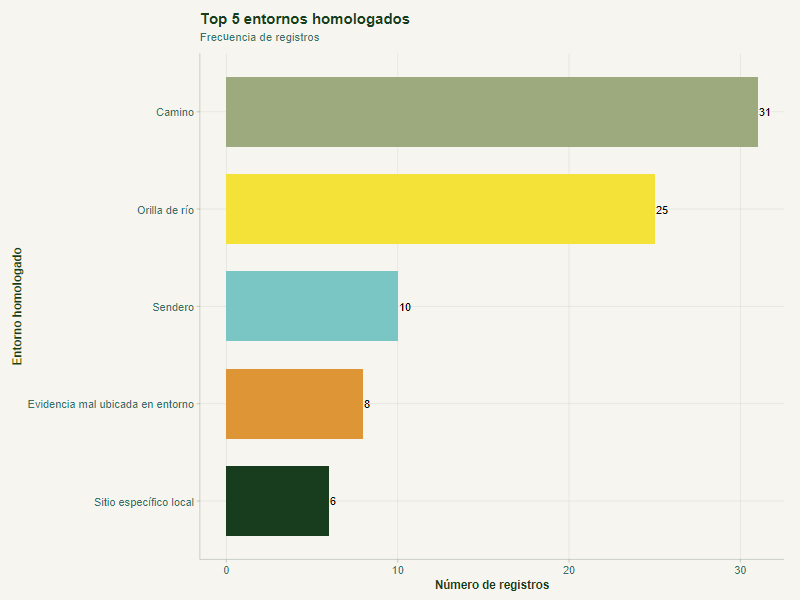

In [34]:
# =========================================================
# 3. Gráfica de barras top 5 entorno homologado
# =========================================================

ggplot(
  top5_entorno,
  aes(x = Entorno_homologado, y = n, fill = Entorno_homologado)
) +
  geom_col(width = 0.72, show.legend = FALSE) +
  geom_text(
    aes(label = n),
    hjust = -0.1,
    size = 3.8
  ) +
  coord_flip() +
  labs(
    title = "Top 5 entornos homologados",
    subtitle = "Frecuencia de registros",
    x = "Entorno homologado",
    y = "Número de registros"
  ) +
  scale_fill_pacha() +
  theme_pachamama(base_size = 13, legend_pos = "none")